# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [3]:
  #Seu código de importação aqui

df = pd.read_csv('CHURN_TELECON_MOD08_pt2.csv', delimiter=',')

df.head(5)

,customerID,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,F,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,M,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,M,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,M,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,No
4,8191-XWSZG,F,0,No,No,52,Yes,No,No internet service,No internet service,No internet service,One year,Mailed check,71.45,1022.95,No


In [4]:
df['Idoso'] = df['Idoso'].replace({0: 'No', 1: 'Yes'})

df.dtypes

,0
customerID,object
Genero,object
Idoso,object
Casado,object
Dependentes,object
Tempo_como_Cliente,int64
Servico_Telefonico,object
Servico_Internet,object
Servico_Seguranca,object
Suporte_Tecnico,object


In [5]:
df.tail(5)

,customerID,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
2483,6188-UXBBR,F,No,Yes,No,38,Yes,No,No internet service,No internet service,No internet service,One year,Credit card (automatic),20.25,814.75,No
2484,2333-KWEWW,M,No,No,No,18,Yes,No,No internet service,No internet service,No internet service,Two year,Credit card (automatic),20.05,388.60,No
2485,5702-SKUOB,F,No,Yes,No,4,Yes,No,No internet service,No internet service,No internet service,Month-to-month,Mailed check,19.60,93.45,No
2486,1134-YWTYF,M,No,Yes,No,27,Yes,DSL,No,Yes,No,Month-to-month,Electronic check,53.80,1389.85,No
2487,6061-GWWAV,M,No,No,Yes,41,Yes,DSL,Yes,No,Yes,One year,Mailed check,70.20,2894.55,No


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [6]:
#Seu código aqui

df.describe()

,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago
count,2488.000000,2488.000000,2488.000000
mean,32.352090,66.342564,2290.087178
std,24.636885,28.051718,2264.585643
min,0.000000,18.400000,18.800000
25%,8.000000,45.400000,402.337500
50%,29.000000,71.450000,1402.900000
75%,56.000000,87.712500,3867.162500
max,72.000000,118.650000,8564.750000


> B)

> É possível que tenha outliers na coluna 'Total_Pago'. Podemos notar que o valor *Max* está bem alto quando comparado com os valores *Min* e *25%* dos valores. Quando comparado com a **Média** e **Mediana** também podemos notar uma divergência alta também.

> C)

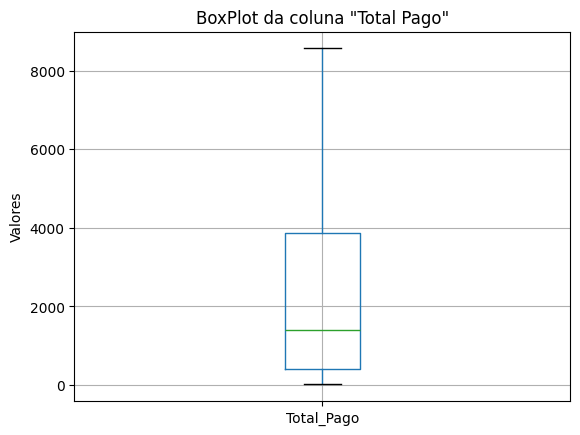

In [7]:
df.boxplot(column = 'Total_Pago')
plt.title('BoxPlot da coluna "Total Pago"')
plt.ylabel('Valores')
plt.show()

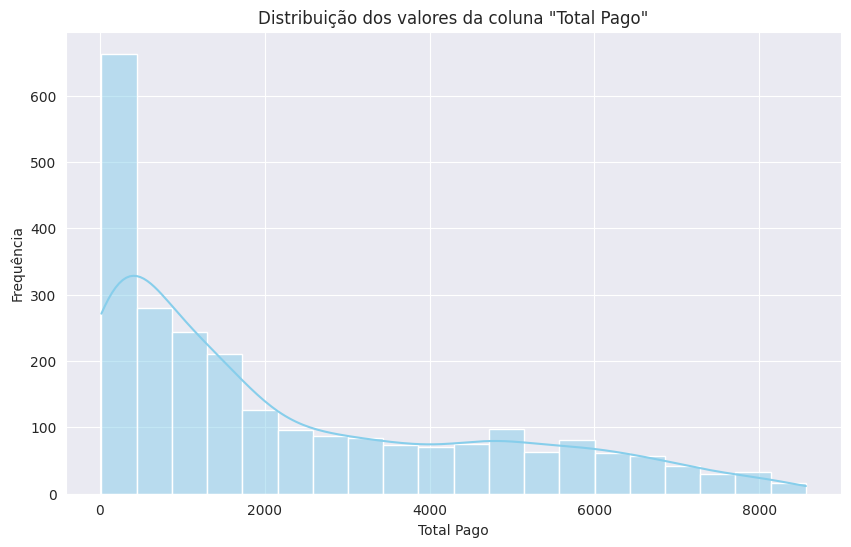

In [8]:
sns.set_style('darkgrid')

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Total_Pago', bins=20, kde=True, color='skyblue')
plt.xlabel('Total Pago')
plt.ylabel('Frequência')
plt.title('Distribuição dos valores da coluna "Total Pago"')
plt.show()

> Foi realizado um estudo na coluna mais suspeita e conter outliers: "Total_Pago". Porém, após gerar os gráficos Boxplot e Histograma, nenhum outlier foi pontuado, apesar de possuir valores discrepantes e com grande peso no valor próximo ao 0.

> Vamos verificar as demais colunas.

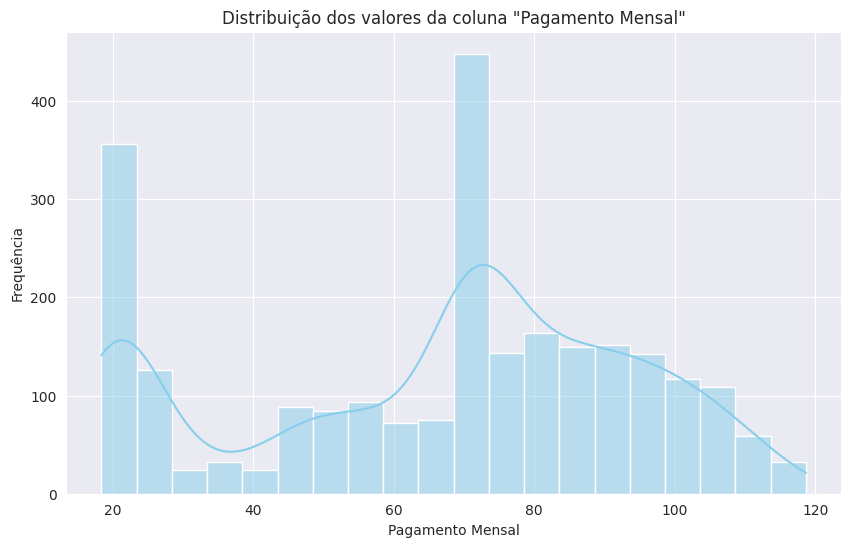

In [9]:
sns.set_style('darkgrid')

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Pagamento_Mensal', bins=20, kde=True, color='skyblue')
plt.xlabel('Pagamento Mensal')
plt.ylabel('Frequência')
plt.title('Distribuição dos valores da coluna "Pagamento Mensal"')
plt.show()

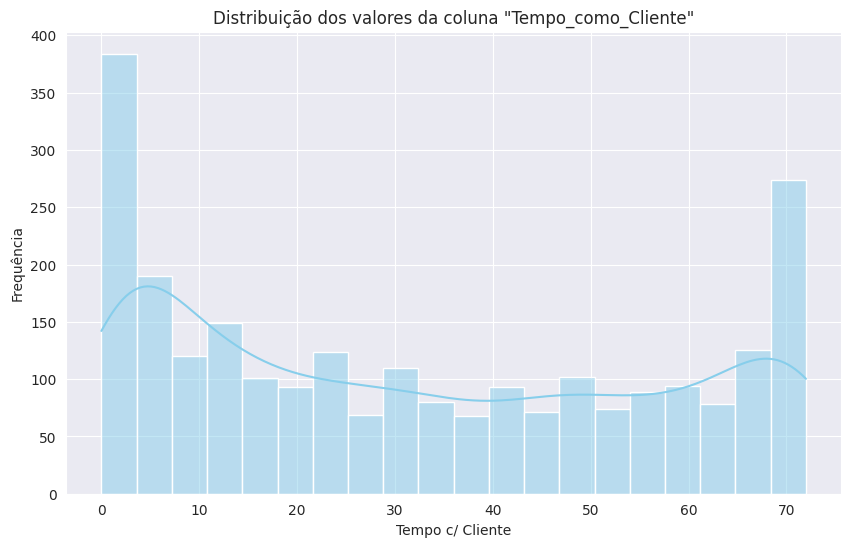

In [10]:
sns.set_style('darkgrid')

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Tempo_como_Cliente', bins=20, kde=True, color='skyblue')
plt.xlabel('Tempo c/ Cliente')
plt.ylabel('Frequência')
plt.title('Distribuição dos valores da coluna "Tempo_como_Cliente"')
plt.show()

> Após a verificação utilizando o Boxplot, pode-se inferir que não há outliers nas colunas do Data Frame. Apesar de conter valores discrepantes, não possui outliers.

> Isso pode se dar ao fato de alguns problemas, um dele é a digitação errada de valores no Data Frame ou pela forma que o mesmo foi preenchido.



---



> D) Análise da coluna Churn a fim de verificar se está bem distribuída.

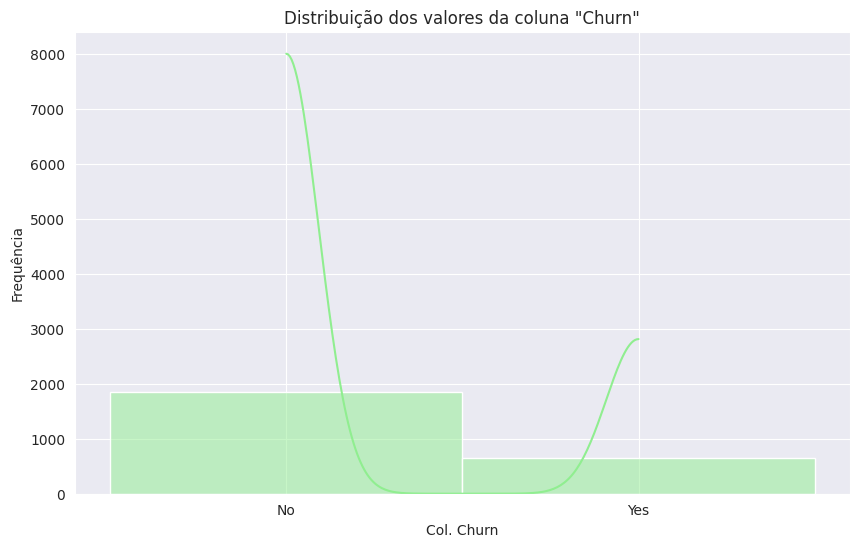

In [11]:
sns.set_style('darkgrid')

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Churn', bins=20, kde=True, color='lightgreen')
plt.xlabel('Col. Churn')
plt.ylabel('Frequência')
plt.title('Distribuição dos valores da coluna "Churn"')
plt.show()

In [12]:
df['Churn'].value_counts(normalize = True) * 100

,proportion
Churn,
No,73.995177
Yes,26.004823


> Os valores "No" representam grande parte do Data Frame, em que é três vezes maior em quantidade quando comparado com os valores "Yes".

> Definitivamente não são balanceados.

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


> Como validado nas questão 2, não há outliers no Data Frame.

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

> B)

> Acredito que as variáveis *Tempo_como_Cliente* e *Total_Pago* sejam as mais adequadas e importantes para relacionar com a variável **"Churn"**